In [1]:
# CNN ResNet for ERA5 Wave Spectra (2D Convolution)
import numpy as np
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
# Load processed data
data_path = "data\processed"
arrays = []

# Load all processed files
for file in os.listdir(data_path):
    print(f"Processing file: {file}")
    full_path = os.path.join(data_path, file)
    print(f"Loading {file}")
    data = np.load(full_path, allow_pickle=False)
    print(f"  Keys: {list(data.keys())}")
    print(f"  X shape: {data['X'].shape}")
    print(f"  y shape: {data['y'].shape}")
    arrays.append(data)

# Combine all samples
total_samples = sum(len(arr['X']) for arr in arrays)
print(f"Total samples: {total_samples}")

# Initialize arrays for combined data
combined_X = []
combined_y = []

for arr in arrays:
    combined_X.append(arr['X'])
    combined_y.append(arr['y'])

# Convert to numpy arrays and extract features
X_combined = np.concatenate(combined_X, axis=0)  # Shape: (samples, 5, 30)
y_combined = np.concatenate(combined_y, axis=0)  # Shape: (samples, 30, 24)

# Extract ALL components from X (use ALL 5 components: S1D, a1, b1, a2, b2)
S1D = X_combined[:, 0, :]  # 1D spectra: (samples, 30)
a1 = X_combined[:, 1, :]   # Directional moment a1: (samples, 30)  
b1 = X_combined[:, 2, :]   # Directional moment b1: (samples, 30)
a2 = X_combined[:, 3, :]   # Directional moment a2: (samples, 30) - INCLUDED
b2 = X_combined[:, 4, :]   # Directional moment b2: (samples, 30) - INCLUDED
S2D = y_combined           # 2D spectra: (samples, 30, 24)

print(f"Data shapes:")
print(f"S1D: {S1D.shape}")  
print(f"S2D: {S2D.shape}")
print(f"a1: {a1.shape}")
print(f"b1: {b1.shape}")
print(f"a2: {a2.shape}")   # NEW
print(f"b2: {b2.shape}")   # NEW

# Check for any NaN values in loaded data

print(f"NaN values in S1D: {np.isnan(S1D).sum()}")
print(f"NaN values in b2: {np.isnan(b2).sum()}")  # NEW

print(f"NaN values in S2D: {np.isnan(S2D).sum()}")
print(f"NaN values in a2: {np.isnan(a2).sum()}")  # NEW

print(f"NaN values in a1: {np.isnan(a1).sum()}")
print(f"NaN values in b1: {np.isnan(b1).sum()}")

Processing file: era5_wave_training.npz
Loading era5_wave_training.npz
  Keys: ['X', 'y', 'freq_hz', 'direction_deg', 'valid_time']
  X shape: (9504, 5, 30)
  y shape: (9504, 30, 24)
Total samples: 9504
Data shapes:
S1D: (9504, 30)
S2D: (9504, 30, 24)
a1: (9504, 30)
b1: (9504, 30)
a2: (9504, 30)
b2: (9504, 30)
NaN values in S1D: 0
NaN values in b2: 0
NaN values in S2D: 0
NaN values in a2: 0
NaN values in a1: 0
NaN values in b1: 0


<>:2: SyntaxWarning: invalid escape sequence '\p'
<>:2: SyntaxWarning: invalid escape sequence '\p'
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15680\3598381509.py:2: SyntaxWarning: invalid escape sequence '\p'
  data_path = "data\processed"


In [3]:
# Prepare inputs for CNN ResNet model (ALL moments)
print("Preparing inputs for CNN ResNet model...")

# Create model inputs by concatenating ALL features
# Input features: S1D (30) + a1 (30) + b1 (30) + a2 (30) + b2 (30) = 150 features
batch_size, n_freq, n_dir = S2D.shape
n_features = n_freq * 5  # ALL 5 components

# Flatten and concatenate ALL inputs
inputs = np.concatenate([
    S1D.reshape(batch_size, -1),  # Shape: (batch_size, 30)  
    a1.reshape(batch_size, -1),   # Shape: (batch_size, 30)
    b1.reshape(batch_size, -1),   # Shape: (batch_size, 30)
    a2.reshape(batch_size, -1),   # Shape: (batch_size, 30) - NEW
    b2.reshape(batch_size, -1)    # Shape: (batch_size, 30) - NEW
], axis=1)  # Final shape: (batch_size, 150)

# Target is the FULL 2D spectrum (direct regression)
targets = S2D.reshape(batch_size, -1)  # Shape: (batch_size, 30*24=720)

print(f"Input shape: {inputs.shape}")
print(f"Target shape: {targets.shape}")
print(f"Input features: {n_features} (S1D + a1 + b1 + a2 + b2)")

# Check for any remaining NaN values
nan_inputs = np.isnan(inputs).sum()
nan_targets = np.isnan(targets).sum()
print(f"NaN in inputs: {nan_inputs}")
print(f"NaN in targets: {nan_targets}")

if nan_inputs > 0 or nan_targets > 0:
    print("WARNING: NaN values detected! Will clean...")
    # Find rows with any NaN
    input_mask = ~np.isnan(inputs).any(axis=1)
    target_mask = ~np.isnan(targets).any(axis=1)
    valid_mask = input_mask & target_mask
    
    print(f"Valid samples: {valid_mask.sum()}/{len(valid_mask)}")
    
    # Filter out NaN samples
    inputs = inputs[valid_mask]
    targets = targets[valid_mask]
    S2D = S2D[valid_mask]
    print(f"Cleaned input shape: {inputs.shape}")
    print(f"Cleaned target shape: {targets.shape}")

# Basic statistics
print(f"Input range: [{inputs.min():.6f}, {inputs.max():.6f}]")
print(f"Target range: [{targets.min():.6f}, {targets.max():.6f}]")

print(f"Input mean: {inputs.mean():.6f}, std: {inputs.std():.6f}")
print(f"Target mean: {targets.mean():.6f}, std: {targets.std():.6f}")

Preparing inputs for CNN ResNet model...
Input shape: (9504, 150)
Target shape: (9504, 720)
Input features: 150 (S1D + a1 + b1 + a2 + b2)
NaN in inputs: 0
NaN in targets: 0
Input range: [-0.991445, 22.504860]
Target range: [0.000000, 19.814178]
Input mean: -0.121308, std: 0.506509
Target mean: 0.025833, std: 0.173907


In [4]:
# Normalize inputs and split data
print("Normalizing inputs and splitting data...")

# Normalize inputs to improve training stability
input_mean = inputs.mean(axis=0, keepdims=True)
input_std = inputs.std(axis=0, keepdims=True) + 1e-8  # Add small epsilon for numerical stability
inputs_norm = (inputs - input_mean) / input_std

# Save normalization parameters for later evaluation (proper deployment practice)
os.makedirs("models", exist_ok=True)
np.savez("models/resnet_normalization.npz", input_mean=input_mean, input_std=input_std)
print(f"💾 Saved normalization parameters to models/resnet_normalization.npz")


# For targets, use raw 2D spectrum without scaling
targets_norm = targets
target_scale = 1.0  # No scaling applied

print(f"Input normalization - Mean: {input_mean.mean():.6f}, Std: {input_std.mean():.6f}")
print(f"Target scaling factor: {target_scale:.6f}")
print(f"Normalized input range: [{inputs_norm.min():.6f}, {inputs_norm.max():.6f}]")
print(f"Normalized target range: [{targets_norm.min():.6f}, {targets_norm.max():.6f}]")

# Split data chronologically (proper for time-series wave data)
n_samples = len(inputs_norm)
n_train = int(0.7 * n_samples)
n_val = int(0.15 * n_samples)
n_test = n_samples - n_train - n_val

# Don't shuffle - preserve temporal structure
indices = np.arange(n_samples)  # Chronological order
train_idx = indices[:n_train]
val_idx = indices[n_train:n_train+n_val]
test_idx = indices[n_train+n_val:]

# Create splits
X_train, y_train = inputs_norm[train_idx], targets_norm[train_idx]
X_val, y_val = inputs_norm[val_idx], targets_norm[val_idx]
X_test, y_test = inputs_norm[test_idx], targets_norm[test_idx]

# Split 2D for evaluation
S2D_train = S2D[train_idx]
S2D_val = S2D[val_idx]
S2D_test = S2D[test_idx]

print(f"Data splits:")
print(f"Train: {X_train.shape[0]} samples")
print(f"Val: {X_val.shape[0]} samples")
print(f"Test: {X_test.shape[0]} samples")

# Convert to PyTorch tensors
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.FloatTensor(y_train).to(device)
X_val_t = torch.FloatTensor(X_val).to(device)
y_val_t = torch.FloatTensor(y_val).to(device)
X_test_t = torch.FloatTensor(X_test).to(device)

Normalizing inputs and splitting data...
💾 Saved normalization parameters to models/resnet_normalization.npz
Input normalization - Mean: -0.121308, Std: 0.339513
Target scaling factor: 1.000000
Normalized input range: [-8.264766, 23.587287]
Normalized target range: [0.000000, 19.814178]
Data splits:
Train: 6652 samples
Val: 1425 samples
Test: 1427 samples
Using device: cpu


In [2]:
# Define CNN Residual Block
class CNNResidualBlock(nn.Module):
    def __init__(self, channels, kernel_size=3, dropout_rate=0.1):
        super(CNNResidualBlock, self).__init__()
        
        padding = kernel_size // 2  # Same padding
        
        self.conv1 = nn.Conv2d(channels, channels, kernel_size, padding=padding)
        self.bn1 = nn.BatchNorm2d(channels)
        self.relu1 = nn.ReLU()
        
        self.conv2 = nn.Conv2d(channels, channels, kernel_size, padding=padding)
        self.bn2 = nn.BatchNorm2d(channels)
        
        self.dropout = nn.Dropout2d(dropout_rate)
        self.final_relu = nn.ReLU()
    
    def forward(self, x):
        # Save input for skip connection
        identity = x
        
        # First convolution
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu1(out)
        out = self.dropout(out)
        
        # Second convolution
        out = self.conv2(out)
        out = self.bn2(out)
        
        # Add skip connection
        out += identity
        
        # Final activation
        out = self.final_relu(out)
        
        return out

# Define CNN ResNet
class CNNResNet(nn.Module):
    def __init__(self, input_size, hidden_channels=64, num_blocks=3, dropout_rate=0.1):
        super(CNNResNet, self).__init__()
        
        self.input_size = input_size
        self.hidden_channels = hidden_channels
        self.num_blocks = num_blocks
        
        # Project 1D features to 2D feature map
        # 150 → (64 × 30 × 24)
        self.projection = nn.Linear(input_size, hidden_channels * 30 * 24)
        
        # CNN residual blocks
        self.res_blocks = nn.ModuleList([
            CNNResidualBlock(hidden_channels, kernel_size=3, dropout_rate=dropout_rate) 
            for _ in range(num_blocks)
        ])
        
        # Final convolution to single channel
        self.final_conv = nn.Conv2d(hidden_channels, 1, kernel_size=3, padding=1)
        
        # Initialize weights
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                # He initialization for ReLU
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                # He initialization for linear layers
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
    
    def forward(self, x):
        batch_size = x.shape[0]
        
        # Project to 2D feature map
        x = self.projection(x)  # (batch, 64*30*24)
        x = x.reshape(batch_size, self.hidden_channels, 30, 24)  # (batch, 64, 30, 24)
        
        # Apply residual blocks
        for block in self.res_blocks:
            x = block(x)
        
        # Final convolution to single channel
        x = self.final_conv(x)  # (batch, 1, 30, 24)
        x = x.squeeze(1)  # (batch, 30, 24)
        
        # Flatten for MSE loss compatibility
        x = x.reshape(batch_size, -1)  # (batch, 720)
        
        return x



In [ ]:
# Create model
input_size = X_train.shape[1]   # 150 features (S1D + a1 + b1 + a2 + b2)
hidden_channels = 64            # CNN hidden channels
num_blocks = 3                  # Number of CNN residual blocks

model = CNNResNet(input_size, hidden_channels, num_blocks).to(device)

print(f"CNN ResNet model created:")
print(f"Input size: {input_size} (S1D + a1 + b1 + a2 + b2)")
print(f"Hidden channels: {hidden_channels}")
print(f"Output size: 720 (30 freq × 24 dir)")
print(f"CNN residual blocks: {num_blocks}")
print(f"Number of parameters: {sum(p.numel() for p in model.parameters()):,}")

# Test forward pass with small batch to check for issues
test_batch = X_train_t[:4]  # Small test batch
with torch.no_grad():
    test_output = model(test_batch)
    print(f"Test output shape: {test_output.shape}")
    print(f"Test output range: [{test_output.min().item():.6f}, {test_output.max().item():.6f}]")
    print(f"Test output has NaN: {torch.isnan(test_output).any().item()}")

print("CNN ResNet architecture defined successfully")

In [6]:
# Training setup
print("Setting up training...")

# Training hyperparameters
learning_rate = 1e-4    # Conservative learning rate
batch_size = 32         # Batch size
num_epochs = 50         # Number of epochs
weight_decay = 1e-5     # L2 regularization

# Create standard data loaders (MSE loss only)
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = TensorDataset(X_val_t, y_val_t)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Optimizer and scheduler
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.7, patience=5)

# Loss function - simple MSE
criterion = nn.MSELoss()

print(f"Training configuration:")
print(f"  Learning rate: {learning_rate}")
print(f"  Batch size: {batch_size}")
print(f"  Number of epochs: {num_epochs}")
print(f"  Weight decay: {weight_decay}")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Loss function: MSE only (no physics constraints)")

# Training history
train_losses = []
val_losses = []
best_val_loss = float('inf')

print("Ready to start CNN ResNet training")

Setting up training...
Training configuration:
  Learning rate: 0.0001
  Batch size: 32
  Number of epochs: 50
  Weight decay: 1e-05
  Train batches: 208
  Val batches: 45
  Loss function: MSE only (no physics constraints)
Ready to start CNN ResNet training


In [ ]:
# CNN ResNet training loop
model_path = "models/resnet2.pth"  # Path to save best model

print("Starting CNN ResNet training...")

for epoch in range(num_epochs):
    # Training phase
    model.train()
    epoch_train_loss = 0.0
    train_batches = 0
    
    for batch_idx, (batch_x, batch_y) in enumerate(train_loader):
        optimizer.zero_grad()
        
        # Forward pass
        pred = model(batch_x)
        
        # Compute MSE loss
        loss = criterion(pred, batch_y)
        
        # Check for NaN 
        if torch.isnan(loss):
            print(f"NaN loss detected at epoch {epoch+1}, batch {batch_idx+1}")
            print(f"  Pred range: [{pred.min().item():.6f}, {pred.max().item():.6f}]")
            print(f"  Loss: {loss.item()}")
            break
        
        # Backward pass
        loss.backward()
        
        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        # Check for NaN gradients
        grad_norms = [p.grad.norm().item() if p.grad is not None else 0 for p in model.parameters()]
        if any(np.isnan(gn) for gn in grad_norms):
            print(f"NaN gradients detected at epoch {epoch+1}, batch {batch_idx+1}")
            break
        
        optimizer.step()
        
        # Accumulate losses
        epoch_train_loss += loss.item()
        train_batches += 1
        
        # Print progress every 50 batches
        if (batch_idx + 1) % 50 == 0:
            print(f"  Batch {batch_idx+1}/{len(train_loader)}, Loss: {loss.item():.6f}")
    
    # Validation phase
    model.eval()
    epoch_val_loss = 0.0
    val_batches = 0
    
    with torch.no_grad():
        for batch_idx, (batch_x, batch_y) in enumerate(val_loader):
            # Forward pass
            pred = model(batch_x)
            
            # Compute MSE loss
            loss = criterion(pred, batch_y)
            
            if not torch.isnan(loss):
                epoch_val_loss += loss.item()
                val_batches += 1
    
    # Average losses
    avg_train_loss = epoch_train_loss / max(train_batches, 1)
    avg_val_loss = epoch_val_loss / max(val_batches, 1)
    
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    
    # Print epoch summary
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"  Train Loss: {avg_train_loss:.6f}")
    print(f"  Val Loss: {avg_val_loss:.6f}")
    print(f"  Learning Rate: {optimizer.param_groups[0]['lr']:.2e}")
    
    # Learning rate scheduling
    scheduler.step(avg_val_loss)
    
    # Save best model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), model_path)
        print(f"  ✓ New best CNN ResNet model saved (val_loss: {best_val_loss:.6f})")
    
    print("-" * 60)

print("CNN ResNet training completed!")
print(f"Best validation loss: {best_val_loss:.6f}")

Starting CNN ResNet training...
  Batch 50/208, Loss: 49.702705
  Batch 100/208, Loss: 14.327748
  Batch 150/208, Loss: 6.200383
  Batch 200/208, Loss: 3.433913
Epoch 1/50
  Train Loss: 58.872420
  Val Loss: 1.873019
  Learning Rate: 1.00e-04
  ✓ New best CNN ResNet model saved (val_loss: 1.873019)
------------------------------------------------------------
  Batch 50/208, Loss: 2.237188
  Batch 100/208, Loss: 1.085253
  Batch 150/208, Loss: 0.788833
  Batch 200/208, Loss: 0.691168
Epoch 2/50
  Train Loss: 1.244600
  Val Loss: 0.439635
  Learning Rate: 1.00e-04
  ✓ New best CNN ResNet model saved (val_loss: 0.439635)
------------------------------------------------------------
  Batch 50/208, Loss: 0.606486
  Batch 100/208, Loss: 0.528257
  Batch 150/208, Loss: 0.362835
  Batch 200/208, Loss: 0.307513
Epoch 3/50
  Train Loss: 0.462294
  Val Loss: 0.317490
  Learning Rate: 1.00e-04
  ✓ New best CNN ResNet model saved (val_loss: 0.317490)
------------------------------------------------

In [8]:
# CNN ResNet model evaluation
print("Evaluating CNN ResNet model...")

# Load best model
model.load_state_dict(torch.load(model_path))
model.eval()

# Make predictions on test set
with torch.no_grad():
    test_predictions = model(X_test_t)
    
    # Compute test MSE loss
    test_loss = criterion(test_predictions, torch.FloatTensor(y_test).to(device))

# Convert back to numpy for evaluation
test_predictions_np = test_predictions.cpu().numpy()
test_target_np = S2D_test

# Reshape predictions back to 2D spectrum format
test_predictions_2d = test_predictions_np.reshape(len(test_predictions_np), n_freq, n_dir)

# Compute reconstruction errors
def compute_relative_error(pred, target):
    """Compute relative error with proper handling of small values"""
    # Add small epsilon to avoid division by zero
    epsilon = 1e-15
    target_safe = np.maximum(target, epsilon)
    
    # Relative error
    rel_error = np.abs(pred - target) / target_safe
    
    # Weight by spectral energy to focus on significant frequencies
    weights = target / (np.sum(target, axis=(1,2), keepdims=True) + epsilon)
    weighted_error = np.sum(weights * rel_error, axis=(1,2))
    
    return np.mean(weighted_error)

# CNN ResNet model error
cnn_resnet_error = compute_relative_error(test_predictions_2d, test_target_np)

# L2 norm error calculation
print("Computing L2 norm error...")

# Remove NaN values for error computation
y_true_clean = np.nan_to_num(test_target_np, nan=0.0)
y_pred_clean = np.nan_to_num(test_predictions_2d, nan=0.0)

# Relative L2 error per time step
epsilon_l2 = 1e-10  # avoid division by zero
n_time = len(test_target_np)

norm_true = np.linalg.norm(y_true_clean.reshape(n_time, -1), axis=1)
norm_diff = np.linalg.norm((y_pred_clean - y_true_clean).reshape(n_time, -1), axis=1)
relative_l2_error = norm_diff / (norm_true + epsilon_l2)
l2_cnn_resnet_error = np.mean(relative_l2_error)

print("\n" + "="*60)
print("CNN RESNET MODEL EVALUATION RESULTS")
print("="*60)
print("WEIGHTED ENERGY-BASED ERROR:")
print(f"CNN ResNet error:                  {cnn_resnet_error:.6f}")

print("\nL2 NORM ERROR:")
print(f"CNN ResNet L2 error:               {l2_cnn_resnet_error:.6f}")

print(f"\nMSE LOSS:")
print(f"Test MSE Loss:                     {test_loss.item():.6f}")

# Additional statistics
print(f"\nDetailed statistics:")
print(f"Test set size:                     {len(test_target_np)} samples")
print(f"Mean target energy:                {np.mean(np.sum(test_target_np, axis=(1,2))):.6f}")
print(f"Mean CNN ResNet energy:            {np.mean(np.sum(test_predictions_2d, axis=(1,2))):.6f}")

print(f"\nL2 error statistics:")
print(f"CNN ResNet L2 - Mean: {np.mean(relative_l2_error):.6f}, Std: {np.std(relative_l2_error):.6f}")
print(f"CNN ResNet L2 - Min: {np.min(relative_l2_error):.6f}, Max: {np.max(relative_l2_error):.6f}")

print("="*60)

Evaluating CNN ResNet model...
Computing L2 norm error...

CNN RESNET MODEL EVALUATION RESULTS
WEIGHTED ENERGY-BASED ERROR:
CNN ResNet error:                  1.194288

L2 NORM ERROR:
CNN ResNet L2 error:               1.386584

MSE LOSS:
Test MSE Loss:                     0.013643

Detailed statistics:
Test set size:                     1427 samples
Mean target energy:                27.796831
Mean CNN ResNet energy:            25.624126

L2 error statistics:
CNN ResNet L2 - Mean: 1.386584, Std: 2.320345
CNN ResNet L2 - Min: 0.247624, Max: 19.090902


In [9]:
# R-squared (coefficient of determination) calculation for CNN ResNet
print("Computing R-squared values for CNN ResNet model...")

# Flatten the 2D spectra for R-squared calculation
y_true_flat = test_target_np.flatten()
y_pred_cnn_resnet_flat = test_predictions_2d.flatten()

# Calculate R-squared for CNN ResNet model
ss_res_cnn_resnet = np.sum((y_true_flat - y_pred_cnn_resnet_flat) ** 2)
ss_tot = np.sum((y_true_flat - np.mean(y_true_flat)) ** 2)
r2_cnn_resnet = 1 - (ss_res_cnn_resnet / ss_tot)

print("\n" + "="*50)
print("R-SQUARED ANALYSIS (CNN RESNET)")
print("="*50)
print(f"CNN ResNet R²:                     {r2_cnn_resnet:.6f}")

# Interpretation
print(f"\nVariance explained:")
print(f"  CNN ResNet: {r2_cnn_resnet*100:.2f}% of total variance")

# Correlation coefficient
corr_cnn_resnet = np.corrcoef(y_true_flat, y_pred_cnn_resnet_flat)[0, 1]

print(f"\nPearson correlation:")
print(f"  CNN ResNet: {corr_cnn_resnet:.6f}")

print("="*50)

print(f"\nCNN RESNET MODEL SUMMARY:")
print(f"  Input: S1D + a1 + b1 + a2 + b2 → {input_size} features")
print(f"  Architecture: CNN ResNet with {num_blocks} residual blocks")
print(f"  Hidden channels: {hidden_channels}")
print(f"  Output: Direct 2D spectrum → 720 values (30×24)")
print(f"  Activation: ReLU with residual connections")
print(f"  Loss: MSE only (no physics constraints)")
print(f"  Training: {num_epochs} epochs with weight decay")
print(f"  Final Performance:")
print(f"    - Weighted Error: {cnn_resnet_error:.6f}")
print(f"    - L2 Error: {l2_cnn_resnet_error:.6f}")
print(f"    - R²: {r2_cnn_resnet:.6f} ({r2_cnn_resnet*100:.2f}% variance explained)")
print(f"    - Test MSE: {test_loss.item():.6f}")

print(f"\nCNN ResNet Architecture Details:")
print(f"  ✓ Projection Layer: Linear({input_size} → {hidden_channels}×30×24)")
print(f"  ✓ Reshape: (batch, {hidden_channels}, 30, 24)")
print(f"  ✓ CNN Residual Blocks: {num_blocks} blocks with skip connections")
print(f"  ✓ Each Block: Conv2D → BatchNorm → ReLU → Conv2D → BatchNorm → Skip → ReLU")
print(f"  ✓ Final Conv: Conv2D({hidden_channels} → 1) → (batch, 30, 24)")
print(f"  ✓ Total Parameters: {sum(p.numel() for p in model.parameters()):,}")

print("\n✓ CNN ResNet model evaluation completed!")

Computing R-squared values for CNN ResNet model...

R-SQUARED ANALYSIS (CNN RESNET)
CNN ResNet R²:                     0.666708

Variance explained:
  CNN ResNet: 66.67% of total variance

Pearson correlation:
  CNN ResNet: 0.831707

CNN RESNET MODEL SUMMARY:
  Input: S1D + a1 + b1 + a2 + b2 → 150 features
  Architecture: CNN ResNet with 3 residual blocks
  Hidden channels: 64
  Output: Direct 2D spectrum → 720 values (30×24)
  Activation: ReLU with residual connections
  Loss: MSE only (no physics constraints)
  Training: 50 epochs with weight decay
  Final Performance:
    - Weighted Error: 1.194288
    - L2 Error: 1.386584
    - R²: 0.666708 (66.67% variance explained)
    - Test MSE: 0.013643

CNN ResNet Architecture Details:
  ✓ Projection Layer: Linear(150 → 64×30×24)
  ✓ Reshape: (batch, 64, 30, 24)
  ✓ CNN Residual Blocks: 3 blocks with skip connections
  ✓ Each Block: Conv2D → BatchNorm → ReLU → Conv2D → BatchNorm → Skip → ReLU
  ✓ Final Conv: Conv2D(64 → 1) → (batch, 30, 24)


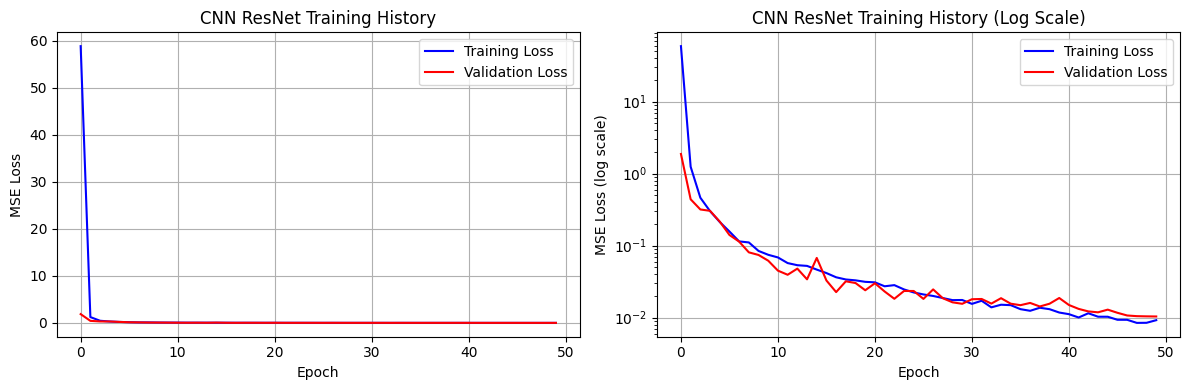


FINAL SUMMARY:
Final training loss: 0.009202
Final validation loss: 0.010357
Best validation loss: 0.010357
Test L2 error: 1.386584
Test R²: 0.666708


In [10]:
# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss', color='blue')
plt.plot(val_losses, label='Validation Loss', color='red')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('CNN ResNet Training History')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_losses, label='Training Loss', color='blue')
plt.plot(val_losses, label='Validation Loss', color='red')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss (log scale)')
plt.title('CNN ResNet Training History (Log Scale)')
plt.yscale('log')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Print final summary
print(f"\nFINAL SUMMARY:")
print(f"Final training loss: {train_losses[-1]:.6f}")
print(f"Final validation loss: {val_losses[-1]:.6f}")
print(f"Best validation loss: {best_val_loss:.6f}")
print(f"Test L2 error: {l2_cnn_resnet_error:.6f}")
print(f"Test R²: {r2_cnn_resnet:.6f}")

# 🌊 Evaluation on Independent Dataset

Evaluate the trained CNN ResNet model on completely separate evaluation data.

In [ ]:
# Load ERA5 evaluation data and normalization parameters
print("Loading ERA5 evaluation data for final assessment...")
model_path = "models/resnet2.pth"
eval_data_path = "eval_data\\processed_0\\era5_wave_eval.npz"
eval_data = np.load(eval_data_path)

print(f"ERA5 evaluation data loaded:")
print(f"  X shape: {eval_data['X'].shape}")
print(f"  y shape: {eval_data['y'].shape}")

# Load normalization parameters
norm_params = np.load("models/resnet_normalization.npz")
eval_input_mean = norm_params['input_mean']
eval_input_std = norm_params['input_std']

print("Normalization parameters loaded for consistent preprocessing")

# Extract evaluation set components
eval_X = eval_data['X']  # Shape: (samples, 5, 30) - S1D, a1, b1, a2, b2
eval_y = eval_data['y']  # Shape: (samples, 30, 24) - 2D spectra

print(f"ERA5 evaluation set: {eval_X.shape[0]} samples")
print(f"Input channels: S1D, a1, b1, a2, b2")

Loading ERA5 evaluation data for final assessment...
ERA5 evaluation data loaded:
  X shape: (1416, 5, 30)
  y shape: (1416, 30, 24)
Normalization parameters loaded for consistent preprocessing
ERA5 evaluation set: 1416 samples
Input channels: S1D, a1, b1, a2, b2


In [4]:
# Preprocess ERA5 evaluation data using existing functions  
print("Preprocessing ERA5 evaluation data...")

# Extract components from evaluation data
eval_S1D = eval_X[:, 0, :]  # 1D spectra: (samples, 30)
eval_a1 = eval_X[:, 1, :]   # Directional moment a1: (samples, 30)
eval_b1 = eval_X[:, 2, :]   # Directional moment b1: (samples, 30)
eval_a2 = eval_X[:, 3, :]   # Directional moment a2: (samples, 30)
eval_b2 = eval_X[:, 4, :]   # Directional moment b2: (samples, 30)

# Prepare inputs for CNN ResNet model (same as training preprocessing)
# Flatten and concatenate ALL inputs like in training
eval_batch_size = eval_X.shape[0]
eval_inputs = np.concatenate([
    eval_S1D.reshape(eval_batch_size, -1),  # Shape: (batch_size, 30)  
    eval_a1.reshape(eval_batch_size, -1),   # Shape: (batch_size, 30)
    eval_b1.reshape(eval_batch_size, -1),   # Shape: (batch_size, 30)
    eval_a2.reshape(eval_batch_size, -1),   # Shape: (batch_size, 30) 
    eval_b2.reshape(eval_batch_size, -1)    # Shape: (batch_size, 30)
], axis=1)  # Final shape: (batch_size, 150)

# Flatten target 2D spectra
eval_targets = eval_y.reshape(eval_batch_size, -1)  # Shape: (batch_size, 720)

print(f"ERA5 evaluation inputs prepared:")
print(f"  Input shape: {eval_inputs.shape} (flattened features)")
print(f"  Target shape: {eval_targets.shape} (flattened 2D spectra)")
print(f"  Input range: [{eval_inputs.min():.6f}, {eval_inputs.max():.6f}]")

# Normalize inputs using saved parameters (same as training)
eval_inputs_norm = (eval_inputs - eval_input_mean) / eval_input_std

print(f"Normalized evaluation inputs:")
print(f"  Range: [{eval_inputs_norm.min():.6f}, {eval_inputs_norm.max():.6f}]")
print(f"  Shape: {eval_inputs_norm.shape}")

# Convert to PyTorch tensors
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
eval_X_tensor = torch.FloatTensor(eval_inputs_norm).to(device)
eval_y_tensor = torch.FloatTensor(eval_targets).to(device)

print(f"ERA5 evaluation data ready for model inference")
print(f"  Device: {device}")
print(f"  Input tensor shape: {eval_X_tensor.shape}")
print(f"  Target tensor shape: {eval_y_tensor.shape}")

Preprocessing ERA5 evaluation data...
ERA5 evaluation inputs prepared:
  Input shape: (1416, 150) (flattened features)
  Target shape: (1416, 720) (flattened 2D spectra)
  Input range: [-0.991445, 78.916193]
Normalized evaluation inputs:
  Range: [-10.202552, 98.689312]
  Shape: (1416, 150)
ERA5 evaluation data ready for model inference
  Device: cpu
  Input tensor shape: torch.Size([1416, 150])
  Target tensor shape: torch.Size([1416, 720])


In [5]:
# Evaluate model on ERA5 evaluation set using saved model
print("Evaluating CNN ResNet on ERA5 data...")

# Get dimensions from eval data
n_freq, n_dir = eval_y.shape[1], eval_y.shape[2]  # (30, 24)

# Create fresh model instance for evaluation (same architecture as training)
eval_input_size = 150  # S1D + a1 + b1 + a2 + b2 (5 * 30)
eval_hidden_channels = 64
eval_num_blocks = 3

model = CNNResNet(eval_input_size, eval_hidden_channels, eval_num_blocks).to(device)

# Load best trained model
model.load_state_dict(torch.load("models/resnet.pth"))
model.eval()

# Perform inference on evaluation set
with torch.no_grad():
    # Predict flattened 2D spectra
    eval_pred_flat = model(eval_X_tensor)
    
    print(f"ERA5 evaluation complete:")
    print(f"  Predictions shape: {eval_pred_flat.shape}")
    print(f"  Prediction range: [{eval_pred_flat.min().item():.6f}, {eval_pred_flat.max().item():.6f}]")
    
    # Convert to numpy for analysis
    eval_pred_flat_np = eval_pred_flat.cpu().numpy()
    eval_target_flat_np = eval_y_tensor.cpu().numpy()

# Reshape predictions back to 2D spectrum format for visualization
eval_pred_np = eval_pred_flat_np.reshape(eval_batch_size, n_freq, n_dir)
eval_target_np = eval_y

print(f"  Reshaped predictions: {eval_pred_np.shape}")

# Compute evaluation metrics
eval_mse = np.mean((eval_pred_flat_np - eval_target_flat_np) ** 2)
eval_mae = np.mean(np.abs(eval_pred_flat_np - eval_target_flat_np))

# Compute R-squared for ERA5 evaluation
eval_y_flat = eval_target_flat_np.flatten()
eval_pred_flat = eval_pred_flat_np.flatten()
eval_ss_tot = np.sum((eval_y_flat - np.mean(eval_y_flat)) ** 2)
eval_ss_res = np.sum((eval_y_flat - eval_pred_flat) ** 2)
eval_r2 = 1 - (eval_ss_res / eval_ss_tot)

print(f"ERA5 evaluation metrics:")
print(f"  MSE: {eval_mse:.6f}")
print(f"  MAE: {eval_mae:.6f}")  
print(f"  R²: {eval_r2:.6f} ({eval_r2*100:.2f}% variance explained)")

print("✓ ERA5 evaluation completed successfully")

Evaluating CNN ResNet on ERA5 data...
ERA5 evaluation complete:
  Predictions shape: torch.Size([1416, 720])
  Prediction range: [-11.721375, 55.854553]
  Reshaped predictions: (1416, 30, 24)
ERA5 evaluation metrics:
  MSE: 3.583966
  MAE: 0.837962
  R²: -0.908016 (-90.80% variance explained)
✓ ERA5 evaluation completed successfully


Creating visualization of CNN ResNet results...


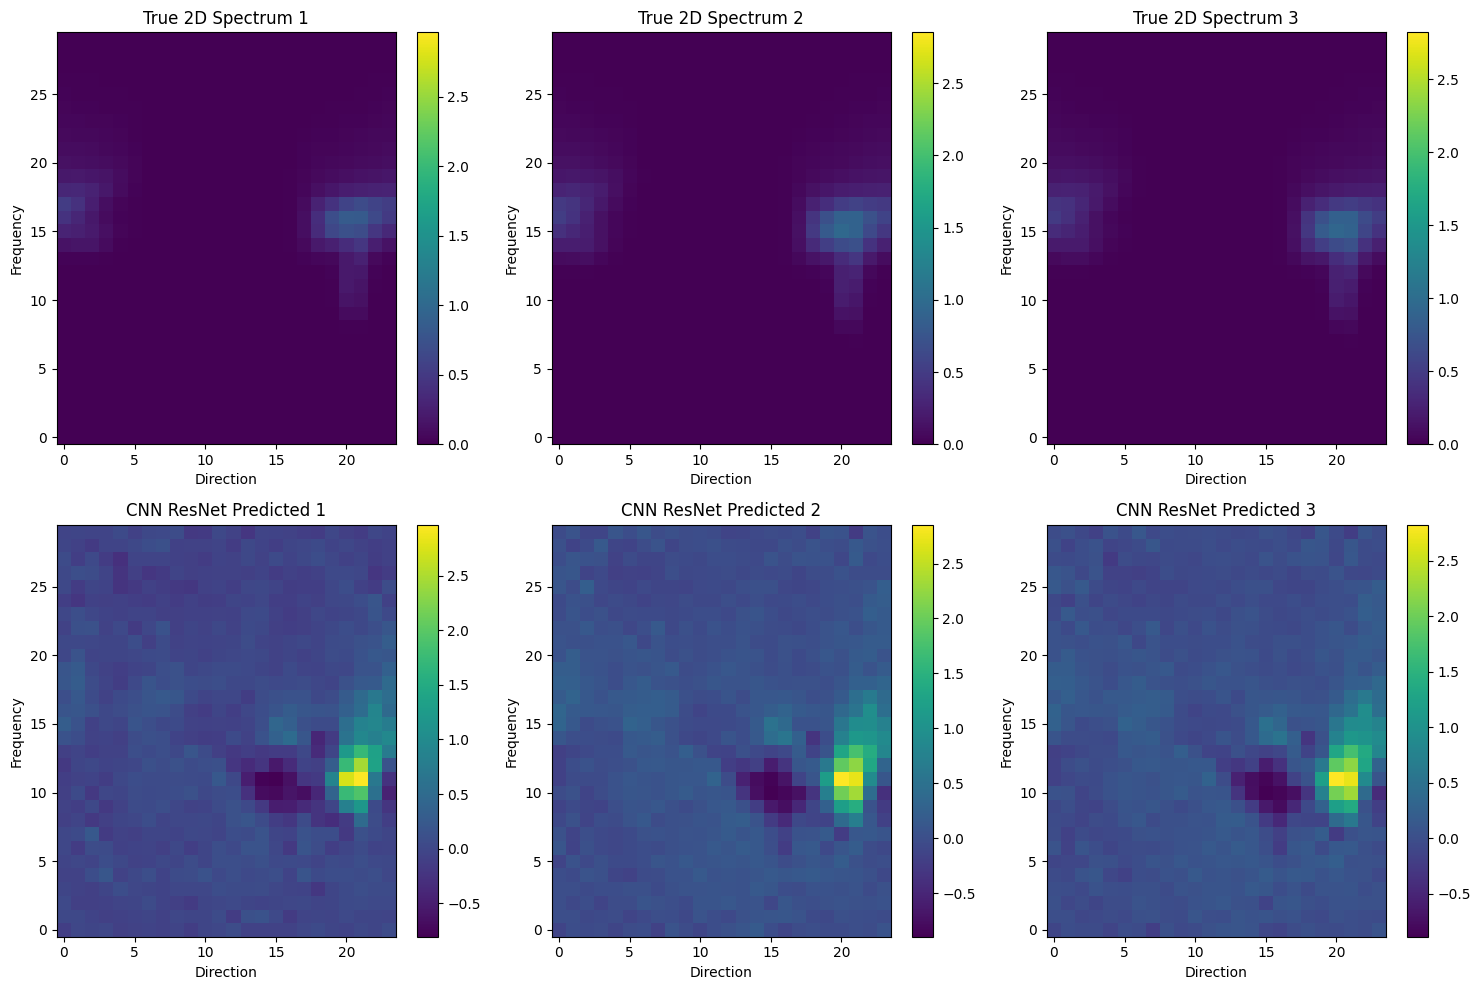

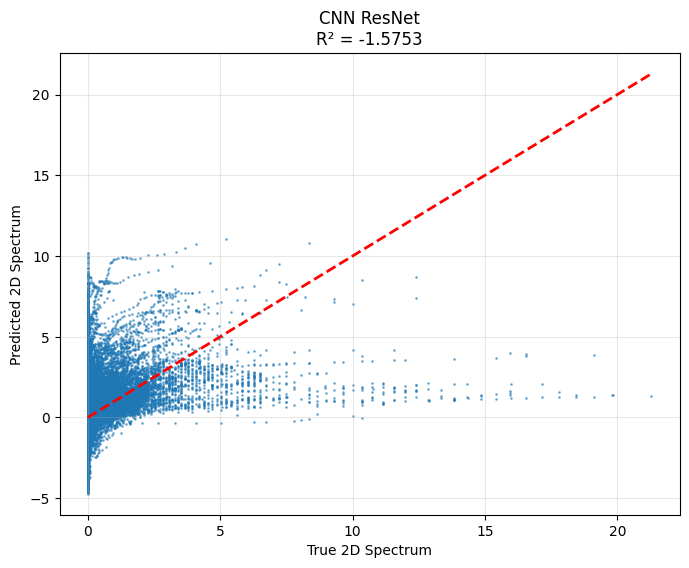

CNN ResNet evaluation completed!


In [6]:
# Visualize ERA5 evaluation results
import matplotlib.pyplot as plt

print("Creating visualization of CNN ResNet results...")

# Select 3 representative samples for visualization
sample_indices = [0, 1, 2]
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Plot heatmaps for 3 timestamps
for i, idx in enumerate(sample_indices):
    sample_target = eval_target_np[idx]
    sample_pred = eval_pred_np[idx]
    
    # Determine common color scale for this timestamp
    vmax = max(sample_target.max(), sample_pred.max())
    
    # Top row: True spectra
    im1 = axes[0,i].imshow(sample_target, cmap='viridis', aspect='auto', origin='lower', vmax=vmax)
    axes[0,i].set_title(f'True 2D Spectrum {idx+1}')
    axes[0,i].set_xlabel('Direction')
    axes[0,i].set_ylabel('Frequency')
    plt.colorbar(im1, ax=axes[0,i])
    
    # Bottom row: Predicted spectra
    im2 = axes[1,i].imshow(sample_pred, cmap='viridis', aspect='auto', origin='lower', vmax=vmax)
    axes[1,i].set_title(f'CNN ResNet Predicted {idx+1}')
    axes[1,i].set_xlabel('Direction')
    axes[1,i].set_ylabel('Frequency')
    plt.colorbar(im2, ax=axes[1,i])

plt.tight_layout()
plt.show()

# R² scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(eval_target_np.flatten(), eval_pred_np.flatten(), alpha=0.5, s=1)
plt.plot([eval_target_np.min(), eval_target_np.max()], [eval_target_np.min(), eval_target_np.max()], 'r--', lw=2)
plt.xlabel('True 2D Spectrum')
plt.ylabel('Predicted 2D Spectrum')
plt.title(f'CNN ResNet\nR² = {eval_r2:.4f}')
plt.grid(True, alpha=0.3)
plt.show()

print("="*70)
print("CNN ResNet evaluation completed!")
print("="*70)